# TEM Tango Control — Client Tutorial

This notebook demonstrates how to connect to and interact with the TEM Tango devices.

All device servers must be running **before** executing this notebook.

Start the HAADF detector:

```bash
uv run python -m tango.test_context asyncroscopy.detectors.CAMERA.CAMERA --host 127.0.0.1 --port 8888
```

Start the Microscope (in a separate terminal):

```bash
uv run python -m tango.test_context asyncroscopy.ThermoMicroscope.ThermoMicroscope \
  --host 127.0.0.1 \
  --port 8889 \
  --prop "{
    'haadf_device_address': 'tango://127.0.0.1:8888/test/nodb/haadf#dbase=no',
    'autoscript_host_ip': '10.46.217.242',
    'autoscript_host_port': 9090
  }"

```

---

If You Get “Address Already in Use”

It means something is already running on that port (likely from a previous session).

To check what is using a port:

```bash
lsof -i :8888
```

Then kill it using the PID shown:

```bash
kill -9 <PID>
```

Quick one-liner:

```bash
kill -9 $(lsof -t -i:8888)
```

Repeat for port `8889` if needed.

---

If a notebook crashes, `tango.test_context` may continue running in the background.
Always stop the previous process before restarting the device server.




## 1. Connect to devices

In [39]:
import json
import numpy as np
import matplotlib.pyplot as plt
import tango

# --nodb mode — use full tango:// URL with port and #dbase=no suffix
haadf_proxy = tango.DeviceProxy("tango://127.0.0.1:8888/test/nodb/haadf#dbase=no")
microscope_proxy = tango.DeviceProxy("tango://127.0.0.1:8889/test/nodb/thermomicroscope#dbase=no")



In [40]:
print('HAADF state     :', haadf_proxy.state())
print('Microscope state:', microscope_proxy.state())

HAADF state     : ON
Microscope state: ON


## 2. Inspect device attributes and commands

In [5]:
print('--- HAADF attributes ---')
for attr in haadf_proxy.get_attribute_list():
    print(f'  {attr}')

print('\n--- Microscope commands ---')
for cmd in microscope_proxy.get_command_list():
    print(f'  {cmd}')

--- HAADF attributes ---
  dwell_time
  image_width
  image_height
  State
  Status

--- Microscope commands ---
  Connect
  Disconnect
  Init
  State
  Status
  get_image
  get_image_data
  get_images


## 3. Configure HAADF detector settings

In [6]:
haadf_proxy.dwell_time 

1e-06

In [7]:
haadf_proxy.dwell_time   = 1e-6   # 1 µs
haadf_proxy.image_width  = 1024
haadf_proxy.image_height = 1024

print('dwell_time  :', haadf_proxy.dwell_time)
print('image_width :', haadf_proxy.image_width)
print('image_height:', haadf_proxy.image_height)

dwell_time  : 1e-06
image_width : 1024
image_height: 1024


## 4. Acquire a HAADF image

In [8]:
# get_image returns DevEncoded = (json_metadata_str, raw_bytes)
json_meta, raw_bytes = microscope_proxy.get_image('haadf')

metadata  = dict(json.loads(json_meta))
image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

print('Metadata:', metadata)
print('Image shape:', image.shape)
print('Image dtype:', image.dtype)

Metadata: {'detector': 'haadf', 'shape': [1024, 1024], 'dtype': 'uint16', 'dwell_time': 1e-06, 'timestamp': 1771975183.333483}
Image shape: (1024, 1024)
Image dtype: uint16


## 5. Display the image

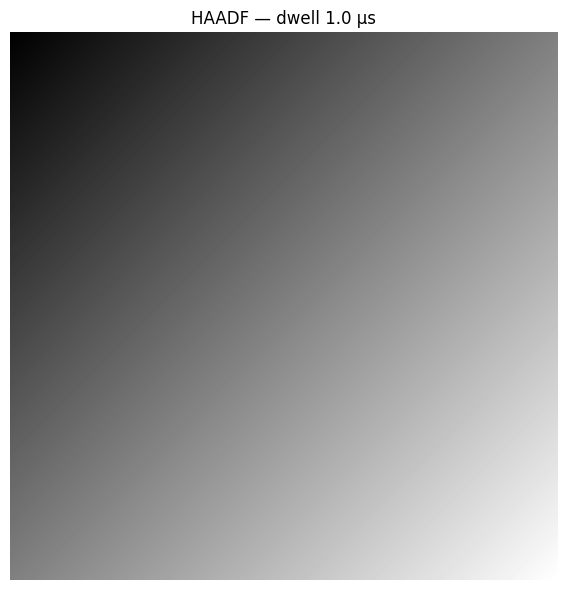

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap='gray', interpolation='none')
ax.set_title(f"HAADF — dwell {metadata['dwell_time']*1e6:.1f} µs")
ax.axis('off')
plt.tight_layout()
plt.show()

### Sidpy dataset

In [10]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

import sidpy
print('sidpy version: ', sidpy.__version__)

sidpy version:  0.12.8


In [11]:
dataset = sidpy.Dataset.from_array(image , name='HAADF')

# set dimesnions
dataset.set_dimension(0, sidpy.Dimension(np.arange(image.shape[0])*.02, 'x'))
dataset.set_dimension(1, sidpy.Dimension(np.arange(image.shape[0])*.02, 'y'))


# set the dataset level plotting metadata
dataset.data_type = 'image'
dataset.units = 'counts'
dataset.quantity = 'intensity'
dataset.title = 'HAADF'

# handle one dimension of the data
dataset.set_dimension(0, sidpy.Dimension(np.arange(dataset.shape[0])*.02, 'x'))
dataset.x.dimension_type = 'spatial'
dataset.x.units = 'nm'
dataset.x.quantity = 'distance'

# handle another dimension of the data

dataset.set_dimension(1, sidpy.Dimension(np.arange(dataset.shape[1])*.02, 'y'))
dataset.y.dimension_type = 'spatial'
dataset.y.units = 'nm'
dataset.y.quantity = 'distance'

In [12]:
dataset.metadata = metadata

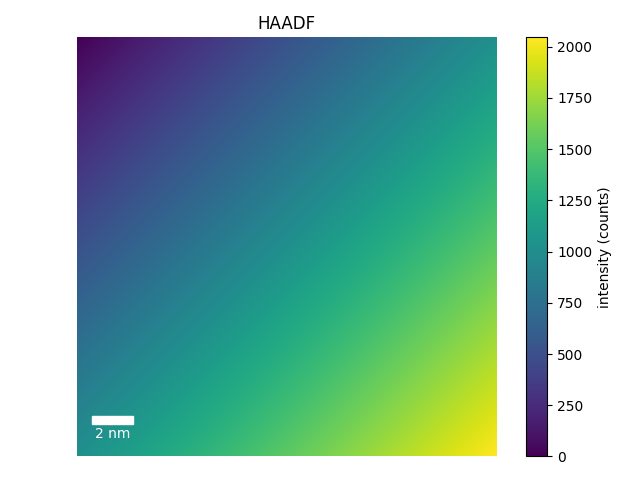

In [14]:
view = dataset.plot(scale_bar=True)

## 6. Advanced acquisition (multi-detector)

#### Start the Advanced acquisiiton

```bash
uv run python -m tango.test_context asyncroscopy.AdvancedAcquisition.AdvancedAcquisition \
  --host 127.0.0.1 \
  --port 8890
```


#### Start the Microscope
```bash
uv run python -m tango.test_context asyncroscopy.Microscope.Microscope --host 127.0.0.1 --port 8889 \
  --prop "{'haadf_device_address': 'tango://127.0.0.1:8888/test/nodb/haadf#dbase=no', 'advanced_acquisition_device_address': 'tango://127.0.0.1:8890/test/nodb/advancedacquisition#dbase=no', 'autoscript_host_ip': '10.46.217.242', 'autoscript_host_port': 9090}"


In [41]:
adv_acq_proxy = tango.DeviceProxy("tango://127.0.0.1:8890/test/nodb/advancedacquisition#dbase=no")


In [42]:
adv_acq_proxy.state()

<DevState.ON: 0>

In [43]:
for attr in adv_acq_proxy.get_attribute_list():
    print(f'  {attr}')



  dwell_time
  base_resolution
  scan_region
  auto_beam_blank
  State
  Status


In [44]:
adv_acq_proxy.dwell_time

1e-06

In [52]:
adv_acq_proxy.scan_region

array([0. , 0. , 0.2, 0.8])

In [ ]:
adv_acq_proxy.scan_region = [0, 0, 1, 1]

In [54]:
# One simultaneous acquisition
response = microscope_proxy.get_images(["HAADF"])
info = json.loads(response)


In [55]:
info

{'images': [{'index': 0,
   'detector': 'haadf',
   'shape': [1024, 1024],
   'dtype': 'uint16',
   'timestamp': 1771975855.342685}],
 'count': 1}

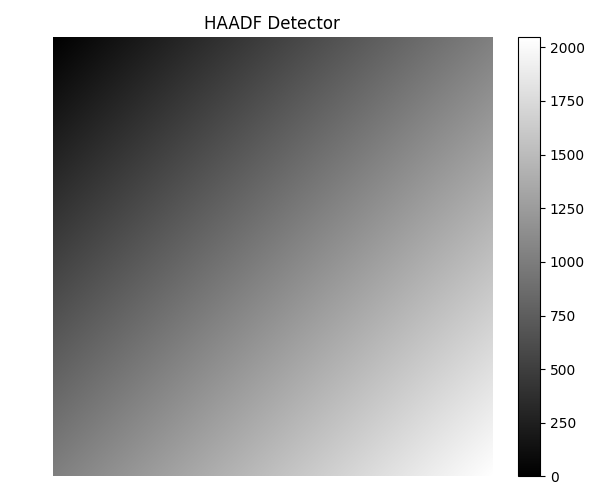

In [56]:
import matplotlib.pyplot as plt

# Quick retrieval
images = []
for img_meta in info["images"]:
    meta_json, img_bytes = microscope_proxy.get_image_data_cached(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    images.append((img_meta["detector"], img))

# Plot all images
fig, axes = plt.subplots(1, len(images), figsize=(6*len(images), 5))

# Handle single image case
if len(images) == 1:
    axes = [axes]

for ax, (detector_name, img) in zip(axes, images):
    im = ax.imshow(img, cmap='gray')
    ax.set_title(f"{detector_name.upper()} Detector")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### get image with rectangular scan region

In [59]:
adv_acq_proxy.scan_region = [0, 0, 0.2, 0.8]
# One simultaneous acquisition
response = microscope_proxy.get_images(["HAADF"])
info = json.loads(response)


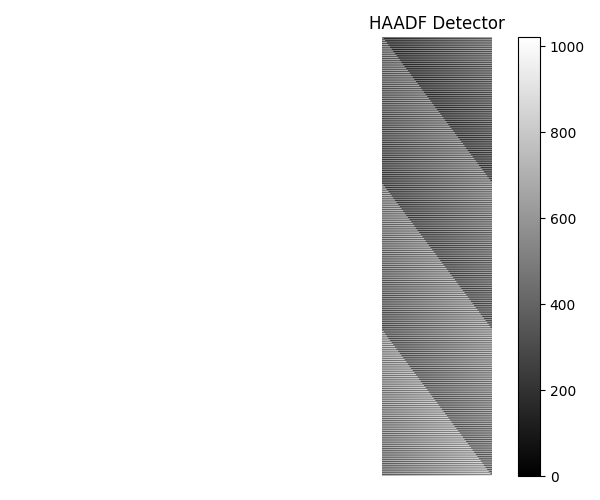

In [60]:
import matplotlib.pyplot as plt

# Quick retrieval
images = []
for img_meta in info["images"]:
    meta_json, img_bytes = microscope_proxy.get_image_data_cached(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    images.append((img_meta["detector"], img))

# Plot all images
fig, axes = plt.subplots(1, len(images), figsize=(6*len(images), 5))

# Handle single image case
if len(images) == 1:
    axes = [axes]

for ax, (detector_name, img) in zip(axes, images):
    im = ax.imshow(img, cmap='gray')
    ax.set_title(f"{detector_name.upper()} Detector")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Sidpy

In [61]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sidpy

# Step 1: Acquire images simultaneously
response = microscope_proxy.get_images(["HAADF"])
info = json.loads(response)

# Step 2: Create sidpy datasets for each image
datasets = []

for img_meta in info["images"]:
    # Get the cached image
    meta_json, img_bytes = microscope_proxy.get_image_data_cached(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    
    # Create sidpy dataset
    dataset = sidpy.Dataset.from_array(img, name=img_meta["detector"])
    
    # Set dimensions (assuming 0.02 nm/pixel - adjust as needed)
    dataset.set_dimension(0, sidpy.Dimension(np.arange(img.shape[0]) * 0.02, 'x'))
    dataset.set_dimension(1, sidpy.Dimension(np.arange(img.shape[1]) * 0.02, 'y'))
    
    # Set dataset metadata
    dataset.data_type = 'image'
    dataset.units = 'counts'
    dataset.quantity = 'intensity'
    dataset.title = img_meta["detector"].upper()
    
    # X dimension metadata
    dataset.x.dimension_type = 'spatial'
    dataset.x.units = 'nm'
    dataset.x.quantity = 'distance'
    
    # Y dimension metadata
    dataset.y.dimension_type = 'spatial'
    dataset.y.units = 'nm'
    dataset.y.quantity = 'distance'
    
    # Store acquisition metadata
    dataset.metadata = img_meta
    
    datasets.append(dataset)



In [62]:
datasets

[sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(819, 204), dtype=uint16, chunksize=(819, 204), chunktype=numpy.ndarray>
  data contains: intensity (counts)
  and Dimensions: 
 x:  distance (nm) of size (819,)
 y:  distance (nm) of size (204,)
  with metadata: ['index', 'detector', 'shape', 'dtype', 'timestamp']]

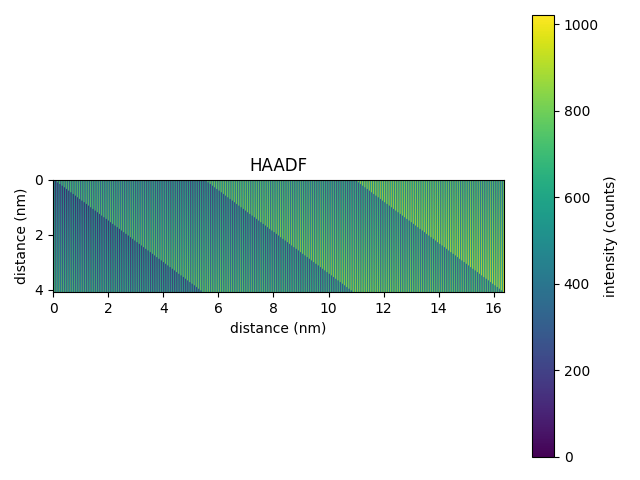

In [64]:
view = datasets[0].plot()